# Classical baseline

Plots the first classical FedAvg baseline (10 clients, 3 rounds) from `results/tables` and saves the figures to `results/plots`.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline

In [2]:
TABLES_DIR = "../results/tables"
PLOTS_DIR  = "../results/plots"

os.makedirs(PLOTS_DIR, exist_ok=True)

configs = {
    "IID (control)":          "classical_iid_a0.5_c10.csv",
    "Dirichlet α=0.5 (moderate skew)": "classical_dirichlet_a0.5_c10.csv",
    "Dirichlet α=0.1 (high skew)":     "classical_dirichlet_a0.1_c10.csv",
}

colors    = ["#2ecc71", "#f39c12", "#e74c3c"]
linestyles = ["-", "--", ":"]

## Convergence

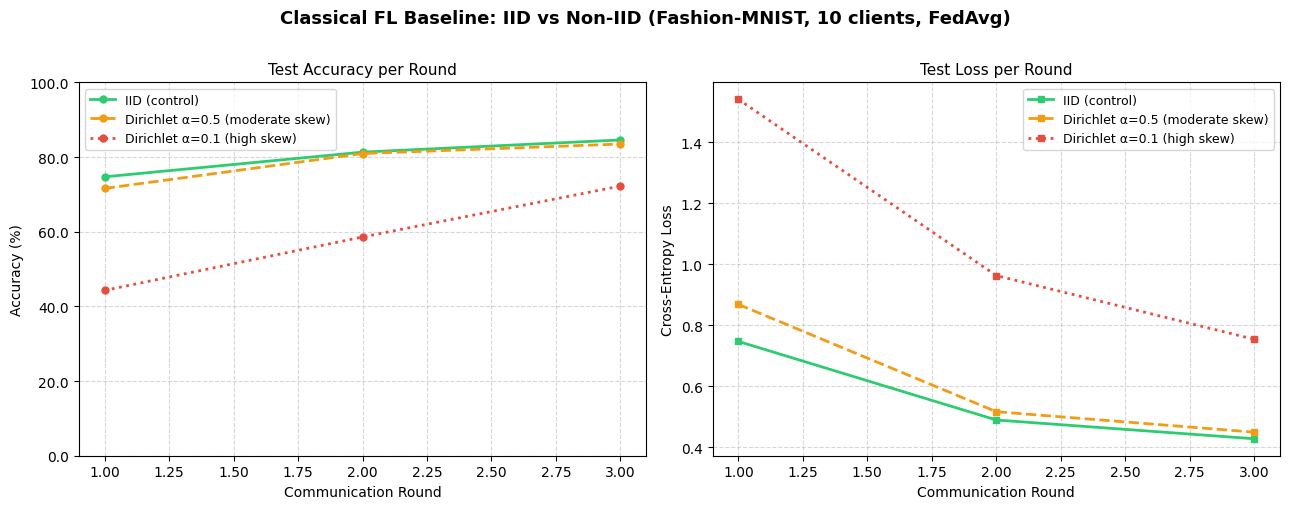

Saved: ../results/plots\baseline_convergence.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Classical FL Baseline: IID vs Non-IID (Fashion-MNIST, 10 clients, FedAvg)",
             fontsize=13, fontweight="bold", y=1.01)

ax_acc, ax_loss = axes

for (label, fname), color, ls in zip(configs.items(), colors, linestyles):
    path = os.path.join(TABLES_DIR, fname)
    if not os.path.exists(path):
        print(f"Missing: {path}, run the baseline first")
        continue
    df = pd.read_csv(path)
    ax_acc.plot(df["round"], df["accuracy"] * 100, label=label,
                color=color, linestyle=ls, marker="o", linewidth=2, markersize=5)
    ax_loss.plot(df["round"], df["loss"], label=label,
                 color=color, linestyle=ls, marker="s", linewidth=2, markersize=5)

ax_acc.set_title("Test Accuracy per Round", fontsize=11)
ax_acc.set_xlabel("Communication Round")
ax_acc.set_ylabel("Accuracy (%)")
ax_acc.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
ax_acc.legend(fontsize=9)
ax_acc.grid(True, linestyle="--", alpha=0.5)
ax_acc.set_ylim(0, 100)

ax_loss.set_title("Test Loss per Round", fontsize=11)
ax_loss.set_xlabel("Communication Round")
ax_loss.set_ylabel("Cross-Entropy Loss")
ax_loss.legend(fontsize=9)
ax_loss.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
out1 = os.path.join(PLOTS_DIR, "baseline_convergence.png")
plt.savefig(out1, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {out1}")

## Final round accuracy

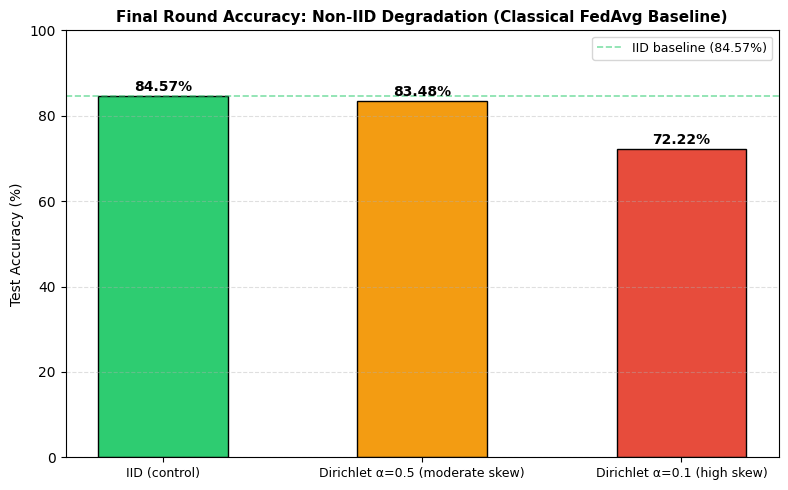

Saved: ../results/plots\baseline_bar_final_acc.png

Non-IID accuracy drop (IID → α=0.1): 12.35%


In [4]:
labels_bar, accs_bar = [], []
for label, fname in configs.items():
    path = os.path.join(TABLES_DIR, fname)
    if not os.path.exists(path):
        continue
    df = pd.read_csv(path)
    labels_bar.append(label)
    accs_bar.append(df["accuracy"].iloc[-1] * 100)

fig2, ax2 = plt.subplots(figsize=(8, 5))
bars = ax2.bar(range(len(labels_bar)), accs_bar, color=colors[:len(labels_bar)],
               edgecolor="black", width=0.5)

for bar, val in zip(bars, accs_bar):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"{val:.2f}%", ha="center", va="bottom", fontweight="bold")

ax2.set_xticks(range(len(labels_bar)))
ax2.set_xticklabels(labels_bar, fontsize=9)
ax2.set_ylabel("Test Accuracy (%)")
ax2.set_title("Final Round Accuracy: Non-IID Degradation (Classical FedAvg Baseline)",
              fontsize=11, fontweight="bold")
ax2.set_ylim(0, 100)
ax2.grid(axis="y", linestyle="--", alpha=0.4)
ax2.axhline(accs_bar[0], color=colors[0], linestyle="--", linewidth=1.2, alpha=0.6,
            label=f"IID baseline ({accs_bar[0]:.2f}%)")
ax2.legend(fontsize=9)

plt.tight_layout()
out2 = os.path.join(PLOTS_DIR, "baseline_bar_final_acc.png")
plt.savefig(out2, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {out2}")

print(f"\nNon-IID accuracy drop (IID → α=0.1): {accs_bar[0] - accs_bar[-1]:.2f}%")